# Epstein Files 

## Introduzione 
Gli [Epstein Files](https://en.wikipedia.org/wiki/Epstein_files) sono i documenti investigativi che riguardano il notorio faccendiere pedofilo Jeffrey Epstein. In totale, i file occupano 300 GB.  

![image](Images/FirsAmendment.jpg)


### Storia e date del rilascio degli Epstein Files

##### Dataset Ufficiali 
Le due principali fonti ufficiali sono: 

-  I documenti rilasciati direttamente dal dipartimento di giustizia seguendo le direttive di [Epstein Files Transparency Act](https://www.congress.gov/bill/119th-congress/house-bill/4405)

-  I documenti richiesti dal congresso. La cronologia del rilascio di questi documenti, per cui non c'è nessun obbligo di renderli pubblici, è ben descritta [qui](https://github.com/markramm/EpsteinFiles/blob/main/DOCUMENT_SOURCES.md)

Molti di questi file sono doppioni. Ecco un'esempio





 DOJ Released                  |   House Released
:---------------------------------:|:-----------------:
 <img src="Images/EFTA01333513.jpg" width="400">  |  <img src="Images/DOJ-OGR-00030902.jpg" width="400">                  


Mentre lavoravo su questo progetto, molti utenti hanno pubblicato programmi e motori di ricerca fatti ad hoc. Uno dei migliori, online e molto esauriente, [è questo](https://epsteingraph.com/)

##### File Rimossi o Censurati

Prima del Epstein Files Transparency Act, ci sono state delle pubblicazioni giornalistiche di alcuni di questi file, che poi sono stati pubblicati nei dataset ufficiali. 

A complicare la faccenda, il fatto che alcuni documenti sono stati pubblicati e poi ritirati, perché (o con la scusa che) alcuni di questi contenevano dati non censurati delle vittime. Esempi di questi dataset sono: 
- Il [dataset 9] (https://www.justice.gov/epstein/doj-disclosures/data-set-9-files) del Dipartimento di Giustizia americano consisteva inizialmente in 180 Gb di files. Per via della presenza di una foto contenente nudi di una vittima è stato ritirato e poi ripubblicato. [La comunità di Reddit](https://www.reddit.com/r/DataHoarder/comments/1qsfv3j/epstein_9_10_11_12_reddit_keeps_nuking_thread_we/) sta cercando di ricreare il dataset
- Un insieme di file presi dai file chiesti e pubblicati dalla Camera statunitense era stato pubblicato su Hugging Faces sotto il nome di [EPSTEIN_FILES_20K](https://huggingface.co/datasets/tensonaut/EPSTEIN_FILES_20K).  Gli autori, per le ragioni espresse in [questo post di Reddit](https://www.reddit.com/r/LocalLLaMA/comments/1p4urm7/we_are_considering_removing_the_epstein_files/), hanno deciso di rimuovere il file. Purtroppo, la maggior parte dei progetti di datascience usavano questo dataset, che comunque è facilmente scaricabile. 

Censura: oltre il ragionevole dubbio della selettività del processo di rilascio dei file, i documenti sono pesantemente censurati per difentere la pivacy delle vittime. 

##### Cercare tra i File

I dati, così come pubblicati dal DoJ e dalla Camera, sono inutilizzabili ai fini di analisi di dati. Diversi parsing che usano algoritmi di riconoscimento visuale sono presenti in rete. U Un'ottimo motore di ricercha che utilizza anche dati ottenuti dal parsing è [questo](https://epsteingraph.com/)

Inoltre, [la pagina github](https://github.com/markramm/EpsteinFiles/blob/main/DOCUMENT_SOURCES.md) già citata in precedenza permette di costruire un motore online. Nel prosimo paragrafo saremo più esaurienti. 


### Galassia di Parser per gli Epstein Files

Vista l'importanza della questione e la natura delle comunity online, uno zoo di metodi e programmi sono stati sviluppati da utenti in modalità open source. In seguito un elenco di una (molto piccola) parte di questi

##### Parser

Diversi tipi di parser sono stati implementati. Questi sono ottimi a dividere i file pubblicati in vari documenti. La maggior parte, oltre a trasformare l'immagine del testo in una stringa, riconosce i nomi propri e li salva. 
Due ottime pagine github sono [questa](https://github.com/markramm/EpsteinFiles) e [questa](https://github.com/actuallyrizzn/epstein-browser)

##### Parser con Riconoscimento Semantico

La maggior parte di questi parser utilizzano algoritmi più avanzati per riconoscere il contesto di una mail, lo scopo. 
Ad esempio [questa](https://github.com/epstein-docs/epstein-docs.github.io) e [questa](https://github.com/maxandrews/Epstein-doc-explorer). (Quest'ultimo dataset, in particolare, è stato utilizzato per fare quello che volevo fare io. In gergo tecnico è detto ["figata  pazzesca"](https://epsteinvisualizer.com/))


##### Ranking 

Un'altra questione è l'ordine con cui andare a leggere i file una volta che sono stati filtrati. Alcune pagine hanno implementato un [motore di ricerca con ranking](https://github.com/latent-variable/epstein-ranker).  

[Questo programma filtra le mail e le ordina in base a un ranking]() (del quale non mi occupo in questo progetto ì)

##### Altre risorse interessanti 

[Le mail di Epstein in formato Gmail (Jmail)](https://jmail.world)

### Scelta del Dataset

Vista la mole di diversi tipi di formato dati, è bene prima porsi la domanda su cosa studiare e poi scegliere il dataset. 

##### Obiettivi per il Report

- Creare un grafo bipartito, dove i nodi di tipo A sono persone e enti, e i nodi di tipo B sono le mail. L'idea iniziale era di plottare il grafo proiettato sui nodi di tip
- Calcolare metriche di grafo: Connettività, gap spettrale... Vedere se queste metriche
- Parte divertente a cui tengo molto: calcolare la curvatura del grafo.

##### Scendere a Patti col Dataset

"Meglio un dataset imperfetto che esiste che un dataset perfetto che non esiste". 

Nonostante nutra dei dubbi sulla fragilità del metodo di parsing delle relazioni, il dataset che più si avvicina ai miei obiettivi è [la già citata pagina github](https://github.com/maxandrews/Epstein-doc-explorer).

Come da descrizione della pagina github, che ricopio sotto, il dataset è composto da 
```sql
-- Documents table
CREATE TABLE documents (
  id INTEGER PRIMARY KEY AUTOINCREMENT,
  doc_id TEXT UNIQUE NOT NULL,
  file_path TEXT NOT NULL,
  one_sentence_summary TEXT NOT NULL,      -- AI-generated brief summary
  paragraph_summary TEXT NOT NULL,         -- AI-generated detailed summary
  date_range_earliest TEXT,                -- Earliest date mentioned in document
  date_range_latest TEXT,                  -- Latest date mentioned in document
  category TEXT NOT NULL,                  -- Document category
  content_tags TEXT NOT NULL,              -- JSON array of content tags
  analysis_timestamp TEXT NOT NULL,        -- When analysis was performed
  input_tokens INTEGER,                    -- Claude API usage metrics
  output_tokens INTEGER,
  cache_read_tokens INTEGER,
  cost_usd REAL,                          -- Estimated API cost
  error TEXT,                             -- Error message if analysis failed
  created_at DATETIME DEFAULT CURRENT_TIMESTAMP,
  full_text TEXT                          -- Complete document text for search
);
CREATE INDEX idx_documents_doc_id ON documents(doc_id);
CREATE INDEX idx_documents_category ON documents(category);

-- RDF triples (relationships)
CREATE TABLE rdf_triples (
  id INTEGER PRIMARY KEY AUTOINCREMENT,
  doc_id TEXT NOT NULL,
  timestamp TEXT,                         -- When the event occurred
  actor TEXT NOT NULL,                    -- Subject of the relationship
  action TEXT NOT NULL,                   -- Action/verb
  target TEXT NOT NULL,                   -- Object of the relationship
  location TEXT,                          -- Where the event occurred
  actor_likely_type TEXT,                 -- Type of actor (person, organization, etc.)
  triple_tags TEXT,                       -- JSON array of tags
  explicit_topic TEXT,                    -- Explicit subject matter
  implicit_topic TEXT,                    -- Inferred subject matter
  sequence_order INTEGER NOT NULL,        -- Order within document
  top_cluster_ids TEXT,                   -- JSON array of top 3 cluster IDs (materialized)
  created_at DATETIME DEFAULT CURRENT_TIMESTAMP,
  FOREIGN KEY (doc_id) REFERENCES documents(doc_id) ON DELETE CASCADE
);
CREATE INDEX idx_rdf_triples_doc_id ON rdf_triples(doc_id);
CREATE INDEX idx_rdf_triples_actor ON rdf_triples(actor);
CREATE INDEX idx_rdf_triples_timestamp ON rdf_triples(timestamp);
CREATE INDEX idx_top_cluster_ids ON rdf_triples(top_cluster_ids);

-- Entity aliases (deduplication)
CREATE TABLE entity_aliases (
  original_name TEXT PRIMARY KEY,
  canonical_name TEXT NOT NULL,
  reasoning TEXT,                         -- LLM explanation for the merge
  created_at TEXT NOT NULL DEFAULT CURRENT_TIMESTAMP,
  created_by TEXT DEFAULT 'llm_dedupe'    -- Source of the alias
);
```

Vedremo nella sezione di preprocessing che i dati, così come sono, hanno bisogno di pulizia. In particolare, 
-
-
-


In seguito, un esempio di output dei 

Mentre lavoravo sul progetto (2026/02/15) sono usciti altri dataset, alcunni dei quali contengono anche il qullo scelto da me.


Ecco uno stesso documento nel formato rilasciato dalla Camera, dal dipartimento di Giustizia, e i dati che sono presenti di esso nel dataset


 DOJ Released                  |   House Released
:---------------------------------:|:-----------------:
 <img src="Images/EFTA02346130.jpg" width="400">  |  <img src="Images/HOUSE_OVERSIGHT_032390.jpg" width="400">                  
(Una semplice ricerca per data e per nomi porta a [questa notizia]( https://www.nytimes.com/2016/12/12/us/politics/rex-tillerson-secretary-of-state-trump.html) )

In [3]:
###### Dati usati e paragone con gli originali
###### Procediamo ad importare i pacchetti e ad caricare i dati
import sys
import os
import sqlite3 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time
import igraph as ig
import time
import random ## To extract a random subgraph
from pyvis.network import Network
import streamlit.components.v1 as components
from itertools import combinations
#import scipy.sparse as sp

current_dir = os.getcwd()
project_root = os.path.abspath(os.path.join(current_dir, '..'))
if project_root not in sys.path:
    sys.path.append(project_root)
import src.my_utils as utl

warnings.simplefilter(action='ignore', category=FutureWarning)



conn = sqlite3.connect('../Data/data.db') #### The path is going to change 

triples = pd.read_sql('SELECT * FROM rdf_triples', conn)
documents = pd.read_sql('SELECT * FROM documents', conn)  ### Here Maybe we Wish to Select the columns that we actually use
aliases = pd.read_sql('SELECT * FROM entity_aliases',conn)

conn.close()


In [4]:
utl.stampa_info_doc(documents, triples, 'HOUSE_OVERSIGHT_032390', text = True)
#utl.stampa_info_doc(documents, triples, 'HOUSE_OVERSIGHT_011280', text = True)
#documents['doc_id'].loc[30]

-------------------------HOUSE_OVERSIGHT_032390-------------------------

******************************One Sentence Summary******************************
An email exchange between Tom Pritzker and Jeffrey Epstein regarding weather, travel plans to Aspen, and commentary on Rex Tillerson's appointment as Secretary of State.
********************************************************************************


********************************************************************************************************************************************************************************************************************************************************** Information *************************
Category: email
Data Range: From 2016-12-15T08:53:00 to 2016-12-15T15:54:53
********************************************************************************


-------------------------Parsed Relations-------------------------

We have found 4 semantic relations of the kind A did B to C
We are going to 


## Obiettivi 

Altri grafi possono essere trovati [qui](https://epstein-file-explorer.com/network), [qui](https://epsteingraph.com/) e [qui](), gli ultimi due già studiati precedentemente. 

##### Progetti Futuri

- Pesare i legami in base al loro valore semantico 

- Mantenere un dataset con i rilasci ufficiali e non, di documenti in formato leggibile dal calcolatore, insieme ai documenti rilasciati, mantenendo un legame con i file originali. Inoltre, mantenere un campo che punta ai duplicati, così da poter facilmente rimuovere i duplicati mantenendo la struttura dei dataset originali, nella forma in cui sono stati rilasciati 
(Purtroppo la gente non capisce che rendere riproducibili i risultati è l'80% del lavoro. Ci ho messo 4 ore a capire che i file parsati [qui](https://github.com/epstein-docs/epstein-docs.github.io) provenissero dai [Documenti della Corte Federale statunitense](https://drive.google.com/drive/folders/1TrGxDGQLDLZu1vvvZDBAh-e7wN3y6Hoz) )

- Migliorare il parsing, soprattutto la parte semantica, per renderlo più adatto al nostro scopo

- Applicare tutto ai Panama Papers


## Problemi 

- Granularità: I dati non sono uniformi: mentre alcuni sono dei documenti originali interi, altri sono le pagine di questi. Non è chiaro come pesare ciascun documento. Nel primo caso, infatti, si da uguale peso a documenti grandi e piccoli, mentre, nel secondo si da più peso ai documenti più grandi. In realtà il nostro punto di riferimento sono le relazioni semantiche ottenute, che a meno di frasi scritte su più pagine, non dipendono dalla granularità.
- Come mostreremo nell'analisi esplorativa dei dati, molti dati sono inconsistenti.
- 

##### Temporary section
1) Data and safety check 
I want to first see whether the datasets [questa](https://github.com/epstein-docs/epstein-docs.github.io) e [questa](https://github.com/maxandrews/Epstein-doc-explorer) overlap. I prefer the first one, but it onlty has court case. Maybe I can put both of them as a safety check that the parsing is not mad, comparing the true document wth the parsed ones in both cases. However, the first dataset is anoyingly ill named and id does not have a document _id. 

2) Upload of the data and definition of the graph structure

3) Usual gaph statistic , for sure there is some python library. 

4) Defiition of the dual graph (or maybe the bipartite, if this is the case, I shall do it before)

5) Same metrics on the graph whose nodes are emails. I think it is useful to see how information travels

6) The best part, the curvature of the graph

Questions: How .should I treat the time??????

7) Visualization: I will recycle the visualizator of the folder, which is already super cool 

## Exploratory Data Analysis (EDA) E pre

L'EDA è un processo iterativo, dato che molte delle inconsistenze e difformità vengono trovate solo durante il processo di visualizzazione. Noi mostriamo solo il risultato di queste iterazioni.

#### Consistenza 

Dapprima, deduplichiamo i nomi, che, durante il parsing, sono stati riconosciuti in diverse form, e.g., "Epstein", "Jeff", "Jeffrey"..

Dopo procediamo a fare un'analisi di consistenza, nella quale vediamo che ci sono delle relazioni semantiche trovate in un documento non presente nel dataset, e cioé il documento 'HOUSE_OVERSIGHT_013343'. [Una ricerca in rete](https://epsteingraph.com/documents/HOUSE_OVERSIGHT_013343) ci fa vedere che le relazioni semantiche sono concordi con il documento, che provvediamo ad aggiungere al dataset. 

Dopodiché filtriamo i documenti che effettivamente hanno dato luogo a relazioni semantiche. Questi sono errori, documenti pesantemente censurati, e pagine vuote di documenti più lunghi. 

#### Deduplicazione

Nel dataset sono presenti dei duplicati "soft", che sono stati scoperti in un secondo momento tramite l'analisi degli outlier della statistica "information_density". Questi sono documenti che hanno dato origine ai documenti, e che li contenevano in formato .txt. In altre parole, sono i file che sono stati processati per dare origine ai diversi documenti. 

Li rimuoviamo facilmente dai documenti, e filtriamo anche le relazioni semantiche assocuate a questi. Per fortuna, dall'id di questi documenti, finiti per errore, possiamo possiamo ricavare il loro duplicato e verificare che effettivamente stiamo rimuovendo duplicati

#### Pulizia e Visualizzazione

Da un'analisi visiva e individuale dei documenti, rimuoviamo i documenti il cui testo è inferiore ai 100 caratteri e le loro relazioni semantiche associate. 

Visualizziamo la quantità di documenti presenti per categoria, le triple semantiche per documento e per argomento esplicito. 

Visualizziamo la distribuzione delle lunghezze dei documenti e del numero di relazioni semantiche associate. Plottiamo, poi, la distribuzione congiunta di variabili della lunghezza del documento vs  numero di triple semantiche ottenute. 

Infine, definiamo la densità di informazione come il numero di triple semantiche ottenute per 100 caratteri. Verifichiamo che la densità di informazione dipende dalla grandezza dei documenti considerati. Più precisamente, fissiamo una sogla treshold (= 2000) e verifichiamo che la densità di informazione dei diversi documenti con un numero maggiore di caratteri della soglia ha una distribuzione empirica a doppia buca. Verifichiamo che questo comportamento e spiegato da un diverso comportamento della variabile "information_density" rispetto alla categoria di documenti. 

Ipotizziamo, forti dello scatterplot 'lunghezza del documenti (in caratter) vs numero di triple semantiche', che questo è dovuto a una serie di documenti, in formato di libro o di report, che contengono un gran numero di caratteri e per cui il numero di relazioni parsate non cresce di pari passo (in sostanza, danno origine a poche triple semantiche)

(Più probabilmente dovrei definire la variabile log(densita + 1), ma lo farò in futuro)



In [5]:
#------- PULIZIA PRELIMINARE-----------------------------------------------------
## DEDUPLICAZIONE, INCONSISTENZE E FILTRAGGIO:
##
# Deduplichiamo gli alias con cui lo stesso nome è conosciuto
# e.g., 'Epstein' -> 'Jeffrey Epstein'.
# 
print(25*'-' +' DEDUPLICAZIONE ' + 25*'-')
print('Deduplichiamo i nomi canonicizzando i diversi alias')
alias_dict = dict(zip(aliases["original_name"], aliases["canonical_name"])) #Alias dictionary
triples['actor'] = triples['actor'].map(alias_dict).fillna(triples['actor']) # notice that .map is much faster than .replace
triples['target'] =triples['target'].map(alias_dict).fillna(triples['target'])
print('Deduplicazione completa \n*')
##
##
#Cerchiamo NA nella colonna dei doc_ids 
n_nan_documents = sum(documents['doc_id'].isna())
n_nan_triples = sum(documents['doc_id'].isna())
print('Controlliamo i NaN nella colonna doc_id')
print(f'Nella colonna doc_id di documents sono presenti {n_nan_documents} Not a Number')
print(f'Nella colonna doc_id di triples sono presenti {n_nan_triples} Not a Number')
print('*')
##
are_there_duplicates = documents['doc_id'].duplicated()
print('Ci sono doc_id uguali documenti duplicati? ')
print(f'There are {sum(are_there_duplicates)} rows that share the same doc_id')
print( 'Purtroppo, ci sono documenti \033[1mduplicati di file con doc_id\033[0m, come vedremo dopo \n*')
##
## Consistenza dei dati tra i due dataframe 
##
#Primo filtraggio
print('Filtriamo il dataframe documents prendendo solo \ni documenti da cui sono state ottenute relazioni semantiche')
print('Molti di questi sono errori o pagine finali di documenti più larghi\n')
doc_ids_triples = triples['doc_id'].unique()
set_doc_ids_triples = set(doc_ids_triples)
documents = documents[documents['doc_id'].isin(set_doc_ids_triples)]
doc_ids = documents['doc_id'].unique()
set_doc_ids = set(doc_ids)
print('\033[1mC\'è un\inconsistenza nel dataset! \033[0m')
print(f'The number of different documents present in the table doc: {len(doc_ids)}')
print(f'The number of different documents present in the table triples: {len(doc_ids_triples)}')
print('c\'è un documento da cui sono state ottenute triple semantiche che non è inserito nella lista dei documenti\n')
print(f'Il documento è {set_doc_ids_triples - set_doc_ids} \n\033[1mNotaì: se la cella viene runnata una seconda volta, l\'inconsistenza sparisce\033[0m\n')
print('Il documento può essere trovato quì https://epsteingraph.com/documents/HOUSE_OVERSIGHT_013343')
print('Un\'occhiata al documento precedente mostra che le relazioni parsate da esso sono giuste ')
print('Decidiamo tenerlo')
print('***** Inseriamo a mano il documento*****\n\n')
category_documento_perso = documents[ documents['doc_id'] =='HOUSE_OVERSIGHT_013341']['category'].iloc[0]
print(category_documento_perso)
documento_perso = {
    'doc_id':  'HOUSE_OVERSIGHT_013343', 
    'category': 'report',# A research online shows that froom HOUSE_OVERSIGHT_013319 is the sam document, and it is saved here as a report
    'one_sentence_summary': 'Page summarizes allegations that Brunel and the modeling agency MC2, affiliated with Epstein, recruited, housed, and arranged visas for underage girls, reports Brunel visited Epstein in jail approximately 67 times, and cites a June 15, 2010 sworn statement by Maritza Vasquez.',
    'full_text': 'Edwards that Brunel might have been procuring two eight-year-old girls for Epstein to sexuallyabuse. According to widely circulated press reports reviewed by Edwards, Brunel is in his sixties and has a reputation throughout the world (and especially in the modeling industry) as a I addict that has for years molested children through modeling agencies while acting as their agent — conduct that has been the subject of critical reports, books, several news articles and a 60 Minutes documentary on Brunel’s sexual exploitation of underage models. See http://bradmillershero.blogspot.com/2010/08/women-are-objects.html, attached hereto as Exhibit \n “FE.”\n63. Edwards learned that Brumel is also someone that visited Epstein on approximately 67 occasions while Epstein was in jail. See Epstein\'s jail visitor log attached as nd “GG.”\n 64. Edwards learned that Brunel currently runs the modeling agency MC2, a company for which Epstein provides financial support. See Message Pad\'s attached as Exhibit “J” supra Sworn Statement of MC2 employee Maritza Vasquez, June 15, 2010, “Maritza Vasquez Sworn Statement” attached at Exhibit “HH” at 1-16.\n 65. Employees of MC2 told Edwards that Epstein’s numerous condos at 301 East 66 Street in New York were used to house young models. Edwards was told that MC2 modeling agency, affiliated with Epstein and Brunel brought underage girls from all over the world, promising them modeling contracts. Epstein and Brunel would then obtain a visa for these girls, then would charge the underage girls rent, presumably to live as underage prostitutes in the condos. See Maritza Vasquez Sworn Statement, Exhibit “HH” at 7-10, 12-15, 29-30, 39-41, 59-60 and 62-67.\n 25\n HOUSE_OVERSIGHT_013343', 
}
new_row_df = pd.DataFrame([documento_perso])
documents = pd.concat([documents, new_row_df], ignore_index=True)
## The document is not present, but it can be found here. As the 
## https://epsteingraph.com/documents/HOUSE_OVERSIGHT_013343
utl.stampa_info_doc(documents, triples, 'HOUSE_OVERSIGHT_013343') # La funzione stampa è stata modificata per permettere a questo documento di essere plottatp
print('Documento inserito manualmente\n Se il programma gira di nuovo, l\'inconsistenza sparisce \n*')


##
## Un'ulteriore inconsistenza: I documenti da seguenti ID, 
## sono pagine di uno stesso documento, ma la categoria non è la stessa
start_id = 'HOUSE_OVERSIGHT_013319'
end_id = 'HOUSE_OVERSIGHT_013343'

# This creates a new dataframe with only the documents in that range
subset_df = documents[documents['doc_id'].between(start_id, end_id)].copy()
print(f'\033[1mUn\'ulteriore inconsistenza che non correggerem\033[0m: i documenti da {start_id} a {end_id} sono pagine di uno stesso documento')
print('Ma la categoria sotto le quali sono segnate varia. Dovrebbe essere un court filing')
print(subset_df['category'].unique())
####
#### Seconda deduplicazione 
####
##
## 
## Scegliamo i documenti cha hanno dato origine al parsin
####
#### ALTRA FILTRI SUI DOCUMENTI 
#### 
print(25*'-' + ' Filtro Documenti' + 25*'-')
# La pulizia consiste in 
# Hard deduplicates: NO
# Soft deduplicates: A LOT (Scoperti studiando outlier)
# Documenti senza Parsing
# Documenti brevi

print('Molti documenti contengono soft duplicates iniziano con la dicitura TEXT-001- o la dicitura TEXR-002-')
print('Sembrerebbero collezioni di diversi documenti e sono stati parsati per errore probabilmente')
print('Sono stati scoperti durante la fase di controllo degli outlier nella statistica dennsità di informazione')
print('Procediamo ad analizzarli e rimuoverli')
## These are the documents that we want to check if needed to  remove
## They were discovered by an outlier analysis on the statistic "density of information"

## Now we want to check how many of them are duplicates
pattern = r'^TEXT-\d+-(.*)'
documents['real_id_potential'] = documents['doc_id'].str.extract(pattern) # Mi ritorna NA se il doc_id non iniziava per TEXT

set_possible_duplicates = set(documents['real_id_potential'].dropna()) # L'insieme dei doc_id che inizia con TEXT
condition = documents['doc_id'].isin(set_possible_duplicates) # Condizione: I documenti che non sono doppioni di un TEXT
set_duplicates = set(documents[condition]['doc_id']) # L'insieme dei doc_id che hanno un TEXT-001- o TEXT-002 
#print(set_possible_duplicates)
print(f'Il numero di documenti che iniziano per TEXT- è: {len(set_possible_duplicates)}')
print(f'Il numero di questi che sono doppioni  {len(set_duplicates)}')
print(f'Ne restano {len( set_possible_duplicates - set_duplicates)}. \n\033[1m Nota\033[0m, se le celle vengono runnate una seconda volta, il risultato cambia')
print( 'Li andiamo a stampare')
print('Un\'analisi visiva e grossolana di questi documenti rivela che ')
print('si tratta di documenti che contengono al suo interno diversi documenti')
print('Quindi il nome è sbagliato e sono finiti la probabilmente per errore')
print('\033[1m Eliminiamo\033[0m dunque questi documenti, e le relazioni semantiche associate')

# Filtriamo i due dataset
condition = documents['real_id_potential'].isna()
documents = documents[condition]
triples = triples[ triples['doc_id'].isin(documents['doc_id'])]
#for doc in documents[documets]:
#    print(doc)
    #doc_name = doc['doc_id'].loc[0]
    #doc_text = doc['full_text'].loc[0]
    #print(25*'-' + doc_name  + 25*'-')
    #print(80*'*' + '\n')
    #print(doc_text)

# Un ultimo filtro 

treshold = 80 ## Il motivo di scegliere questa soglia è una lettura manuale dei vari documenti droppati 
print('Primo filtro: Eliminiamo i documenti con pochi caratteri.')
print(f'Fissiamo una soglia {treshold} di caratteri minima')
print('sotto la quale, eliminiamo il documento. La scelta del valore')
print(f'{treshold} è dettata da una lettura dei documenti droppati')
condition1 = documents['full_text'].str.len() > treshold
print(f'Abbiamo trovato {sum(~condition1)} documenti con meno di {treshold} caratteri')
print('\033[1m Eliminiamo\033[0m dunque questi documenti, e le relazioni semantiche associate')
print(80*'*' + '\n '+ 80*'*' + '\n')

documents = documents[condition1]
triples = triples[triples['doc_id'].isin(set(documents['doc_id']))]



------------------------- DEDUPLICAZIONE -------------------------
Deduplichiamo i nomi canonicizzando i diversi alias
Deduplicazione completa 
*
Controlliamo i NaN nella colonna doc_id
Nella colonna doc_id di documents sono presenti 0 Not a Number
Nella colonna doc_id di triples sono presenti 0 Not a Number
*
Ci sono doc_id uguali documenti duplicati? 
There are 0 rows that share the same doc_id
Purtroppo, ci sono documenti duplicati di file con doc_id, come vedremo dopo 
*
Filtriamo il dataframe documents prendendo solo 
i documenti da cui sono state ottenute relazioni semantiche
Molti di questi sono errori o pagine finali di documenti più larghi

C'è un\inconsistenza nel dataset! 
The number of different documents present in the table doc: 18125
The number of different documents present in the table triples: 18126
c'è un documento da cui sono state ottenute triple semantiche che non è inserito nella lista dei documenti

Il documento è {'HOUSE_OVERSIGHT_013343'} 
Notaì: se la cella v


------------------------- Fundamental Quantities-------------------------

Il numero di documenti è: 15692
Il numero di triple è: 92058


 * Il  numero di documenti per categoria 

category
email                 4209
report                2814
book_excerpt          2293
media_article         1695
transcript            1127
financial_document     805
court_filing           667
mixed_document         583
memorandum             400
other                  369
Name: doc_id, dtype: int64

 * Il numero di documenti per lunghezza (in unità di 100 caratteri):
Notare che molti documenti sono pagine di documenti più grandi



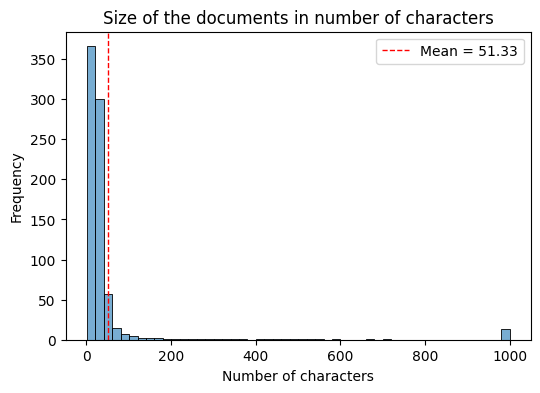


*Vediamo come cambia la distribuzione delle lunghezze considerando le seguenti diverse categorie ['email', 'book_excerpt']


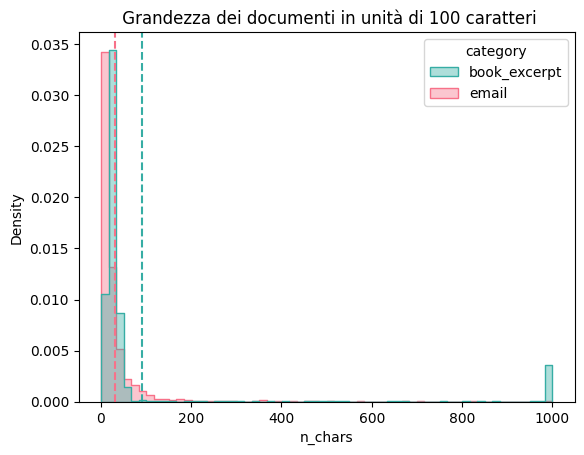

Notiamo che la distribuzione dei frammenti di libri sembra essere, a differenza della distribuzione della lunghezza delle mail, distribuita come la somma di due delta, con molti libri molto poco lunghi e un cluster di estratti di libri di 100000 caratteri. Probabilmente questi sono frammenti di un unico libro più grande, ma evitiamo di indagare ulteriormente.

* Numero di triple per documento: 

The number of triples per document

doc_id
HOUSE_OVERSIGHT_017088_part7    107
HOUSE_OVERSIGHT_027594          107
HOUSE_OVERSIGHT_027460          103
HOUSE_OVERSIGHT_022445           85
HOUSE_OVERSIGHT_017088_part4     79
HOUSE_OVERSIGHT_025452           75
HOUSE_OVERSIGHT_020447_part1     70
HOUSE_OVERSIGHT_027165           69
HOUSE_OVERSIGHT_025707           67
HOUSE_OVERSIGHT_023627           67
dtype: int64

* Numero di triple per explicit_topic: 
explicit_topic
confidentiality and privilege notice       106
biographical death notice                   98
ownership interest documentation   

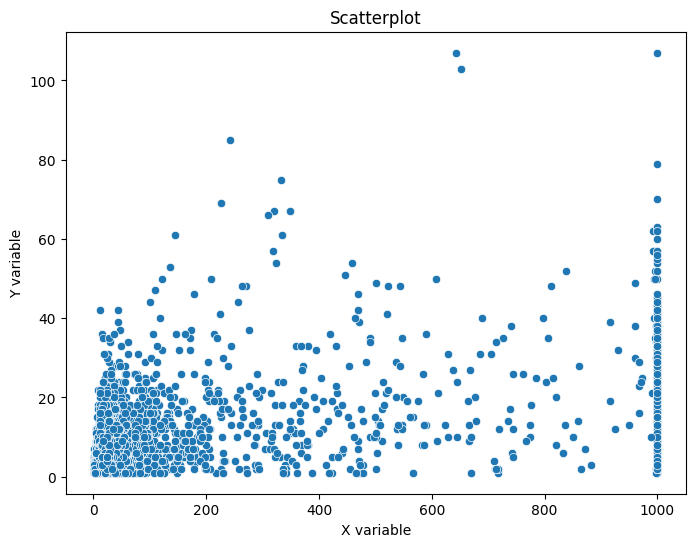

In [6]:
### PRIMA VISUALIZZAZIONE
n_documents = len(documents)
n_triples = len(triples)
print('\n' + 25*'-' +' Fundamental Quantities' +25*'-'  + '\n')
print(f'Il numero di documenti è: {n_documents}')
print(f'Il numero di triple è: {n_triples}\n')

# Documenti per gruppo. Categoria
print('\n * Il  numero di documenti per categoria \n')
print(documents.groupby('category')['doc_id'].count().sort_values(ascending = False).head(10))

# Numero di documenti per lunghezza
print('\n * Il numero di documenti per lunghezza (in unità di 100 caratteri):')
print('Notare che molti documenti sono pagine di documenti più grandi\n')

documents['n_chars'] = documents['full_text'].str.len()/100 # Nuova colonna con la statistica del numero di carateri 

mean_value = documents['n_chars'].mean()
n_bins = 50

plt.figure(figsize=(6,4))
sns.histplot(documents['n_chars'], bins = n_bins, stat = 'frequency', alpha = 0.6)
plt.axvline(mean_value, color='red', linestyle='--', linewidth=1, label=f'Mean = {mean_value:.2f}')
# Labels and title
plt.xlabel('Number of characters')
plt.ylabel('Frequency')
plt.title(f'Size of the documents in number of characters')
plt.legend()
plt.show()

## Tavolazza di colori da usare sempre in  futurp
n_top_categories = 4
top_categories = (
    documents['category']
      .value_counts()
      .head(n_top_categories)
      .index
      .tolist()
) 
colors = sns.color_palette("husl", n_top_categories).as_hex()
category_colors = dict(zip(top_categories, colors))

categorie = ['email', 'book_excerpt']
print(f'\n*Vediamo come cambia la distribuzione delle lunghezze considerando le seguenti diverse categorie {categorie}')

mask = documents['category'].isin(categorie)

doc_plot = documents[mask]
n_bins = 60

sns.histplot(
    data=doc_plot, 
    x='n_chars', 
    hue='category',     # This separates the data by category
    bins=n_bins, 
    palette = category_colors, 
    element="step",     # 'step' or 'poly' makes overlaps easier to see
    stat='density',
    common_norm = False, 
    alpha=0.4,
)

for cat in categorie:
    # Calculate mean for this specific category
    cat_mean = documents[documents['category'] == cat]['n_chars'].mean()
    
    # Get the color from our dictionary
    line_color = category_colors.get(cat)
    
    plt.axvline(
        x=cat_mean, 
        color=line_color, 
        linestyle='--', 
        linewidth=1.5,
        label=f'Mean {cat}' # Optional: this might make the legend very long
    )

plt.title(f" Grandezza dei documenti in unità di 100 caratteri")
plt.show()
print('Notiamo che la distribuzione dei frammenti di libri sembra essere, a differenza della distribuzione della lunghezza delle mail, distribuita come la somma di due delta, con molti libri molto poco lunghi e un cluster di estratti di libri di 100000 caratteri. Probabilmente questi sono frammenti di un unico libro più grande, ma evitiamo di indagare ulteriormente.')

# Numero di triple per documento 
print('\n* Numero di triple per documento: ')
reference_counts = (
    triples.groupby('doc_id')
      .size()
      .rename('n_triples')
      .reset_index()
)
documents = documents.merge( # Nota, se runnato 2 volte il nome della colonna viene cambiato
    reference_counts,
    left_on='doc_id',
    right_on='doc_id',
    how='left'
).fillna(0) # Nuova colonna con il numero di triple per ogni documento
print('\nThe number of triples per document\n')
print(triples.groupby('doc_id').size().sort_values(ascending = False).head(10))

# numero di triple per explicit_topic
print('\n* Numero di triple per explicit_topic: ')
print(triples.groupby('explicit_topic').size().sort_values(ascending = False).head(10))

## Scatterplot di informazione vs lunghezza
# Let's create a row with: 3 categories or others
plt.figure(figsize=(8,6))
#doc_plot = documents[documents['category'].isin(top_categories)] 
doc_plot = documents
sns.scatterplot(
    data=doc_plot,
    x='n_chars',
    y='n_triples',
#    hue='category'   # 👈 this colors by category
)

plt.xlabel('X variable')
plt.ylabel('Y variable')
plt.title('Scatterplot')
plt.show()




------------------------- Bimodalità Densità di Informazione-------------------------

Mostriamo che la densità di informazione ha due comportamenti diversi e non è costante 
    rispetto al numero di caratter di un documento
     
Più precisamente, se consideriamo documenti con un numero di caratteri 
    maggiori di una soglia t, allora la media della densità di informazione decresce.
     
Se da un lato questo è normale, verifichiamo che questa decrescita dell'informazione 
    non è uniforme lung i gruppi e che da origine ad una distribuzione bimodale della densità 
    di informazione nei documenti
     
Ipotizziamo, forti dei grafici, che questo fenomeno è dovuto a un cluster di documenti che sono di categoria "book_excerpt". Non indaghiamo oltre, ma questo diverso comportamento è dovuto al cluster di
    questo tipo di documento, che si vede nello scatter plot, di poca informazione e gran numero di caratteri. Probabilmente sono pezzi di uno stesso libro più grande, che quindi vi

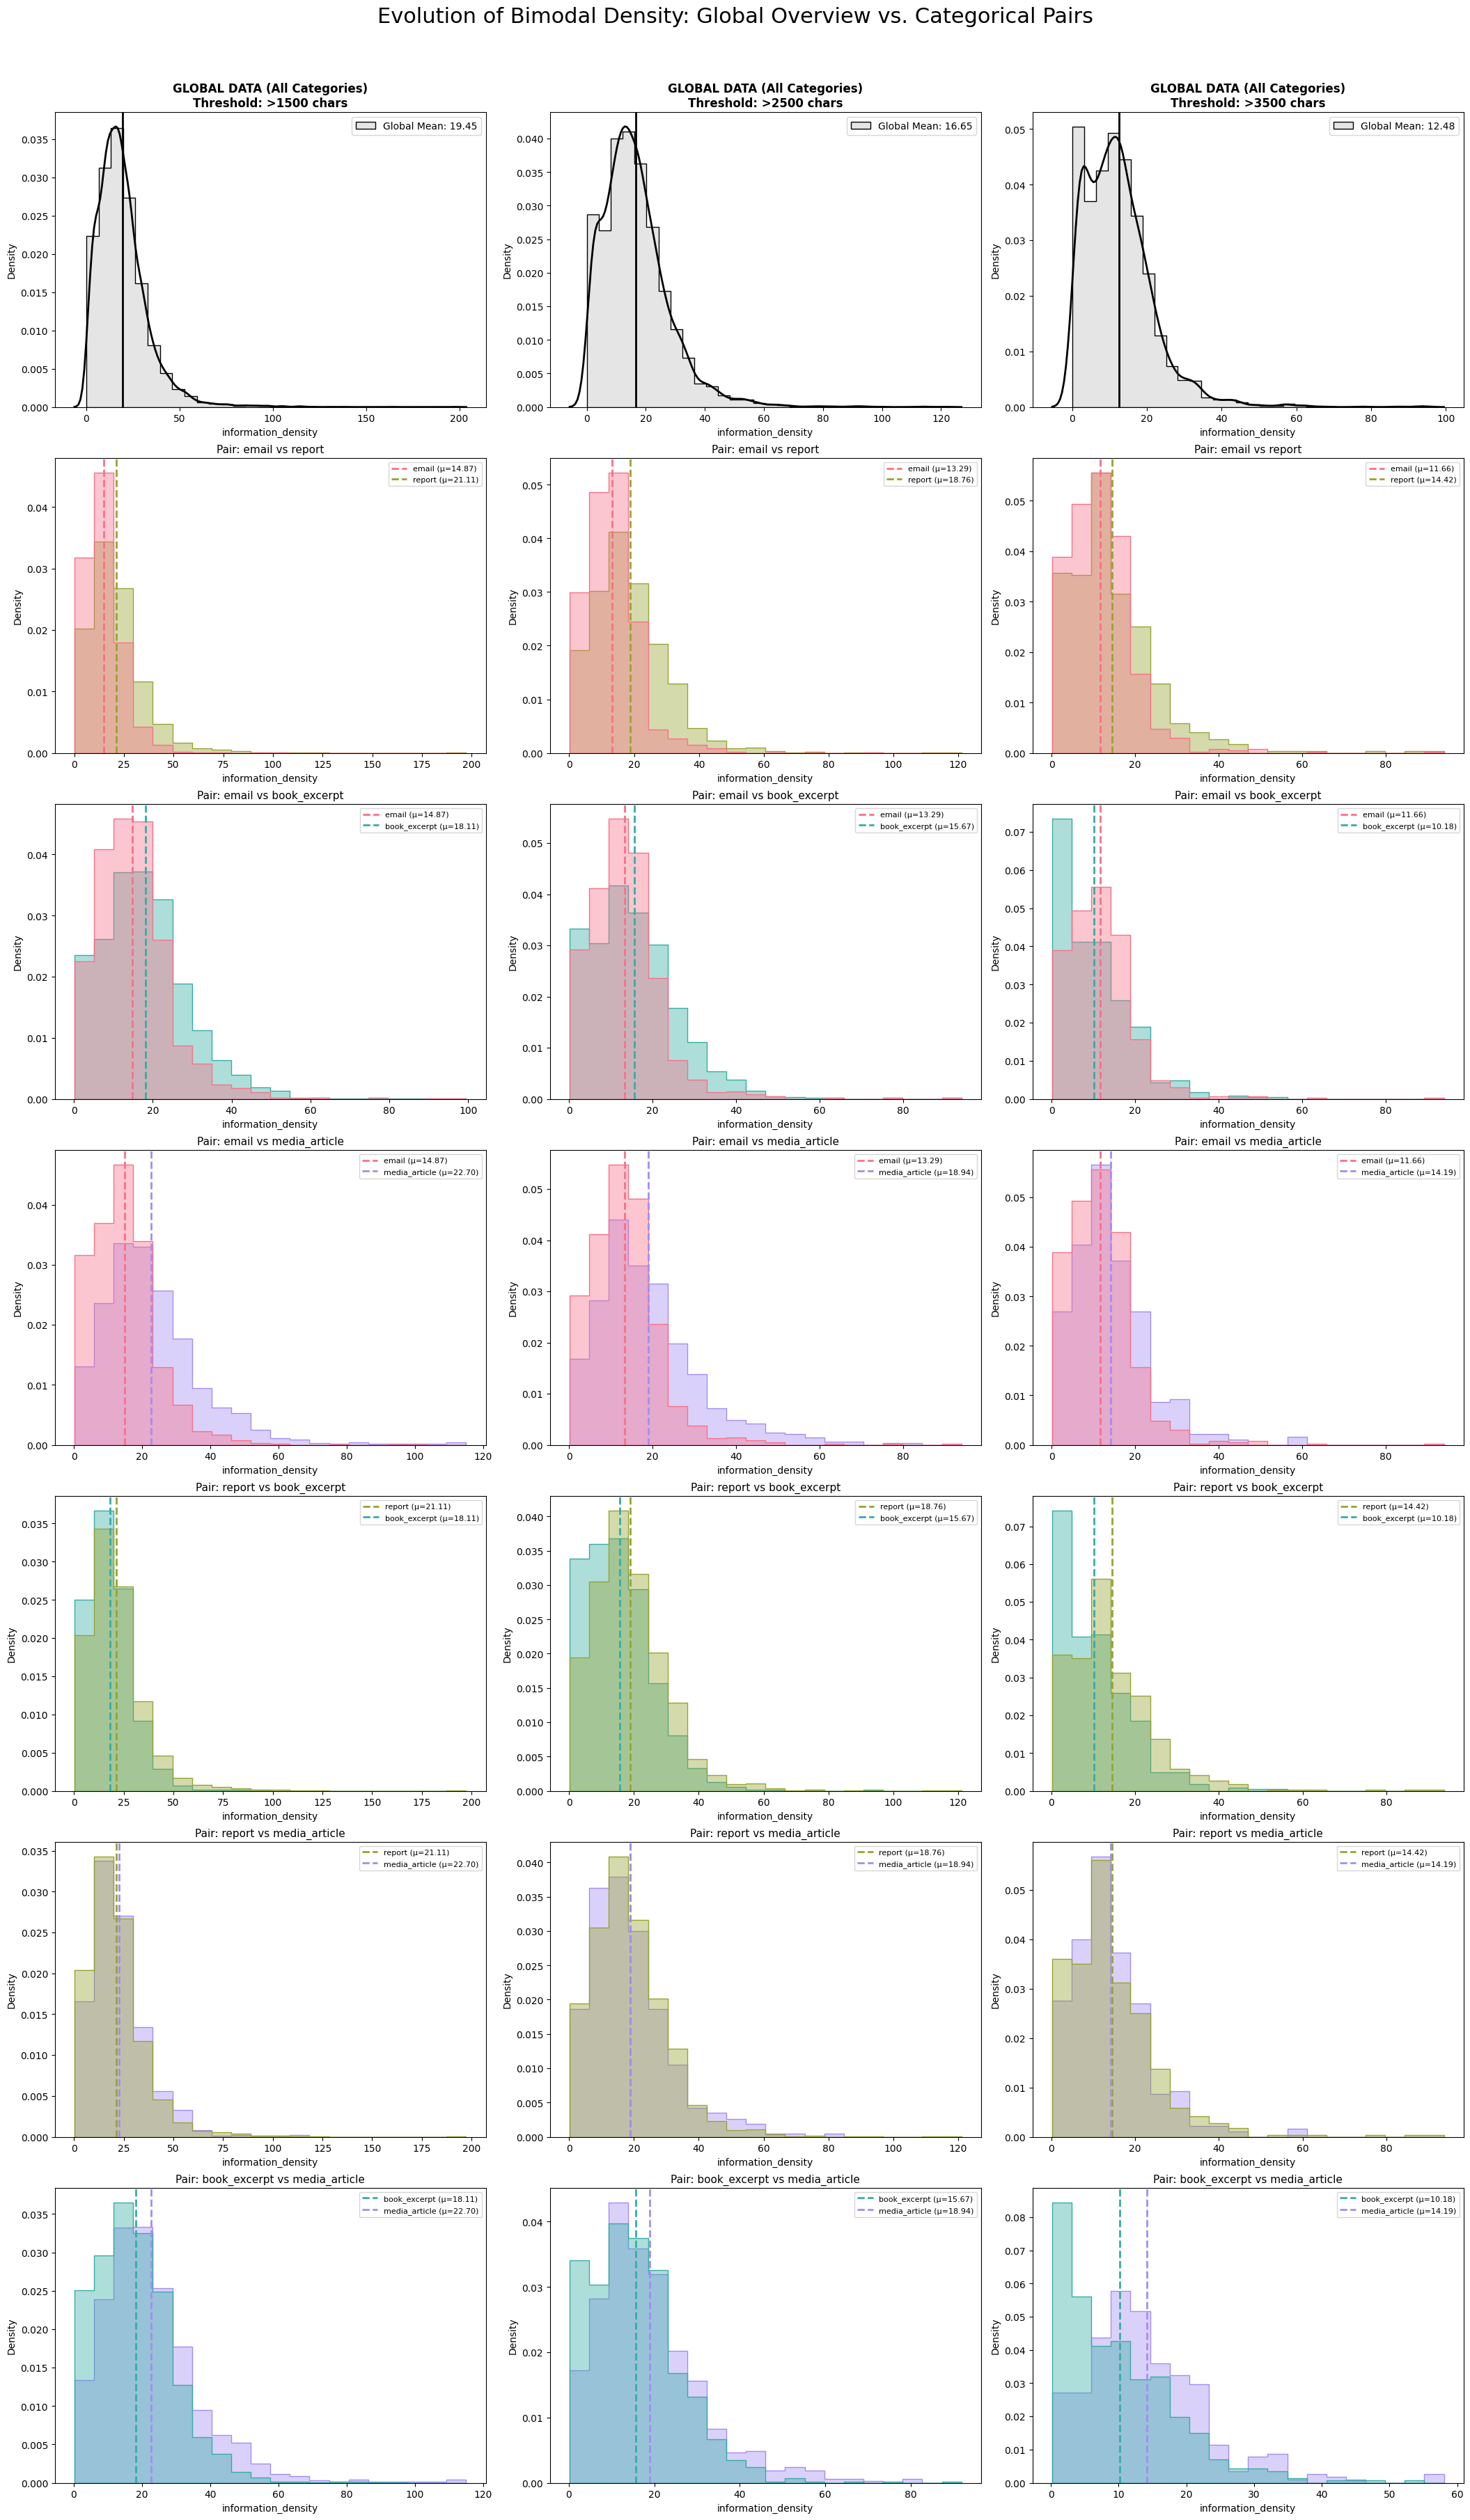

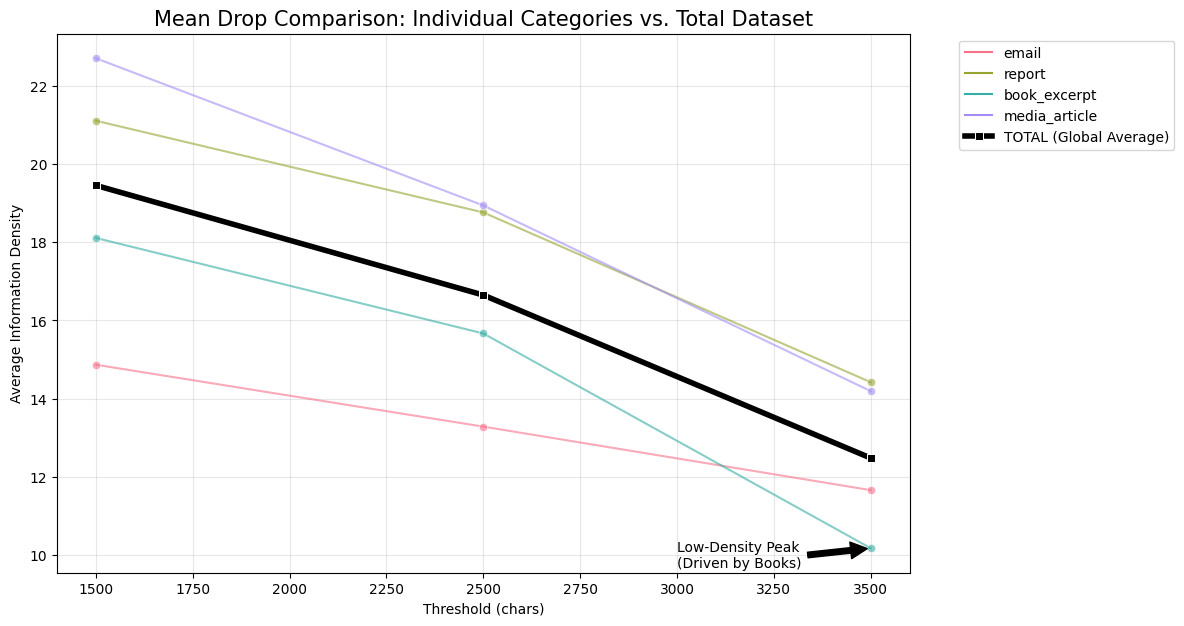

In [7]:
print(25*'-' + ' Bimodalità Densità di Informazione' + 25*'-' + '\n')
print('''Mostriamo che la densità di informazione ha due comportamenti diversi e non è costante 
    rispetto al numero di caratter di un documento
     ''')
print('''Più precisamente, se consideriamo documenti con un numero di caratteri 
    maggiori di una soglia t, allora la media della densità di informazione decresce.
     ''')
print('''Se da un lato questo è normale, verifichiamo che questa decrescita dell\'informazione 
    non è uniforme lung i gruppi e che da origine ad una distribuzione bimodale della densità 
    di informazione nei documenti
     ''')
print('''Ipotizziamo, forti dei grafici, che questo fenomeno è dovuto a un cluster di documenti che sono di categoria "book_excerpt". Non indaghiamo oltre, ma questo diverso comportamento è dovuto al cluster di
    questo tipo di documento, che si vede nello scatter plot, di poca informazione e gran numero di caratteri. Probabilmente sono pezzi di uno stesso libro più grande, che quindi viene pesato troppo nell\'istogramma, ma non indaghiamo oltre.
     ''')
thresholds = [15,25,35] ## n_char è in unità di 1000 caratteri. 
# Andiamo a filtrare i docuumenti con meno di 1000, 2000, e 3000 caratteri 
documents['information_density'] = 100*documents['n_triples']/(documents['n_chars']+1)


from matplotlib.lines import Line2D

warnings.simplefilter(action='ignore', category=FutureWarning)

# 1. Setup dimensions
coppie_categorie = list(combinations(top_categories, 2))
n_rows_pairs = len(coppie_categorie)
n_rows_total = n_rows_pairs + 1 # +1 for the Global Row at the top
n_cols = len(thresholds)

fig, axes = plt.subplots(n_rows_total, n_cols, figsize=(7 * n_cols, 5 * n_rows_total), constrained_layout=True)

# --- ROW 0: THE GLOBAL DISTRIBUTION (NOT DIVIDED BY CATEGORIES) ---
for col_idx, threshold in enumerate(thresholds):
    ax = axes[0, col_idx]
    
    # Filter Total Data
    all_docs_t = documents[documents['n_chars'] >= threshold]
    global_mean = all_docs_t['information_density'].mean()
    
    # Plotting the undivided distribution
    sns.histplot(
        data=all_docs_t, x='information_density', 
        color='black', element="step", stat="density", 
        bins=30, alpha=0.1, ax=ax, label="Undivided Data"
    )
    # Adding a solid outline to make the bimodal shape clear
    sns.kdeplot(data=all_docs_t, x='information_density', color='black', lw=2, ax=ax)
    
    ax.axvline(global_mean, color='black', linestyle='-', linewidth=2)
    ax.legend([f"Global Mean: {global_mean:.2f}"], loc='upper right')
    ax.set_title(f"GLOBAL DATA (All Categories)\nThreshold: >{threshold*100} chars", fontsize=12, fontweight='bold')

# --- ROWS 1 to N: CATEGORY PAIRS ---
for row_idx, pair in enumerate(coppie_categorie):
    current_row = row_idx + 1 # Offset by 1 for the global row
    
    for col_idx, threshold in enumerate(thresholds):
        ax = axes[current_row, col_idx]

        # Filter Data
        all_docs_t = documents[documents['n_chars'] >= threshold]
        cat_mask = all_docs_t['category'].isin(pair)
        doc_plot = all_docs_t[cat_mask].copy()
        
        # Overlapping Histograms for the pair
        sns.histplot(
            data=doc_plot, x='information_density', hue='category', 
            hue_order=pair, palette=category_colors,
            element="step", multiple="layer", stat="density",     
            common_norm=False, bins=20, alpha=0.4, ax=ax, legend=False
        )

        # Legend with Means and Drops
        legend_elements = []
        for cat in pair:
            cat_data = doc_plot[doc_plot['category'] == cat]
            if not cat_data.empty:
                m = cat_data['information_density'].mean()
                c = category_colors.get(cat)
                ax.axvline(m, color=c, linestyle='--', lw=2)
                legend_elements.append(Line2D([0], [0], color=c, lw=2, linestyle='--', 
                                              label=f'{cat} (μ={m:.2f})'))

        ax.legend(handles=legend_elements, loc='upper right', fontsize=8)
        ax.set_title(f"Pair: {pair[0]} vs {pair[1]}", fontsize=11)

plt.suptitle('Evolution of Bimodal Density: Global Overview vs. Categorical Pairs', fontsize=22, y=1.03)
plt.show()



stats_list = []

for t in thresholds:
    # Filter documents based on current threshold
    mask_t = documents['n_chars'] >= t
    temp_df = documents[mask_t]
    
    for cat in top_categories:
        # Calculate mean for the category at this threshold
        cat_data = temp_df[temp_df['category'] == cat]
        if not cat_data.empty:
            mean_val = cat_data['information_density'].mean()
            stats_list.append({
                'Threshold (chars)': t * 100, # Converting units back to characters
                'Category': cat,
                'Mean Density': mean_val,
                'N': len(cat_data)
            })

# Create a summary DataFrame
df_stats = pd.DataFrame(stats_list)

 # Calculate Global Stats
global_stats = []
for t in thresholds:
    mask_t = documents['n_chars'] >= t
    global_mean = documents[mask_t]['information_density'].mean()
    global_stats.append({
        'Threshold (chars)': t * 100,
        'Category': 'TOTAL (Global)',
        'Mean Density': global_mean
    })

df_global = pd.DataFrame(global_stats)

# Plotting
plt.figure(figsize=(11, 7))

# Plot Categories
sns.lineplot(data=df_stats, x='Threshold (chars)', y='Mean Density', 
             hue='Category', palette=category_colors, marker='o', alpha=0.6)

# Add the TOTAL line
sns.lineplot(data=df_global, x='Threshold (chars)', y='Mean Density', 
             color='black', linewidth=4, linestyle='-', marker='s', 
             label='TOTAL (Global Average)', zorder=10)

# Annotate the Bimodal Insight
if 'book_excerpt' in top_categories:
    book_val = df_stats[df_stats['Category'] == 'book_excerpt']['Mean Density'].iloc[-1]
    plt.annotate('Low-Density Peak\n(Driven by Books)', 
                 xy=(thresholds[-1]*100, book_val), 
                 xytext=(thresholds[-1]*100 - 500, book_val - 0.5),
                 arrowprops=dict(facecolor='black', shrink=0.05), fontsize=10)

plt.title('Mean Drop Comparison: Individual Categories vs. Total Dataset', fontsize=15)
plt.ylabel('Average Information Density')
plt.grid(True, alpha=0.3)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()


Per prima cosa deduplichiamo attori e target. In questo modo, "Epstein" e "Jeffrey" non verranno visti come due entità separate. 

#### Problemi con il dataset documents

Molti dei documenti sono si. n

#### Divers


# Work in progress: Please, do not read after this

### Decidiamo Quale Dataset Usare
Il piano è il seguente:
0) Il dataset di Andrews ha tutta la base di dati estratta? Perché non ha i .json risultanti dal suo codice?
1) Prendere un documento in comute, prendere le variabili associate a quel documento nelle varie repository
2) Ispezione grafica
3) Mi serve qua un programmino che mi genera il grafo per il secondo dataset
4) Comparare I grafi usando una qualche metrica.

## 
Statistiche di Grafo

La relazione semantica ha un attore e un target, e chiede fortemente di esserre visualizzata come un grafo. Gli edge, però, non sono variabili categoriche, visto che contengono l'azione effettuata dall'attore sul target, il documento dal quale sono state estratte... 
E' quindi interessante ridurre questa dipendenza degli edge da variabili che possibilmente possano confonderli e considerare, ad esempi, anche i documenti dei nodi. In pratica, tutti gli edge che vanno da un determinato attore a un determinato target, vengono divisi in edge che vanno da un attore al nodo documento, e dal nodo documento al nodo target, creando questo grafo bipartito. Poi, si può anche considerare il grafo duale  

### Metriche Più Interessanti 
Nonostante probabilmente il secondo dataset sia meglio, usiamo il primo, che ha già gli edge pesati (Notare però che sono stati pesati usando K-means, che non mi sembra molto saggia come cosa)
1) Numeri di Betti
2) Autovalori
3) Altre metriche di sicuro sviluppatissime
4) Grafo Bipartito (e quello duale)
5) Vedere clsuter sul grafo duale
6) Principal component analysis sulle mail per vedere se arrivo ad una classifica 

In [9]:
### Generiamo il grafo bipartito, gli altri verranno ottenuti da questo tramite merge
## L'idea è di lasciare negli edge solo variabili di gruppo (e di considerare i documenti come nodi)

rename_AB = {
    'actor': 'source', 
    'doc_id': 'target', 
    }
rename_BA = {
    'doc_id': 'source', 
    'target': 'target',
    }
edges_AB = triples.drop(columns='target').rename(columns =rename_AB)
edges_BA = triples.drop(columns='actor').rename(columns = rename_BA)
edges_bipartite = pd.concat([edges_AB, edges_BA], ignore_index = True)
print('ciao')
nodes = pd.Series(list(edges_bipartite["source"]) + list(edges_bipartite["target"])).unique()
t0  = time.time()
node_type = []
set_actors = set(triples['actor'].values)
set_targets = set(triples['target'].values)
set_docs = set(triples['doc_id'])

entity_set = set_actors.union(set_targets)
node_set = entity_set.union(set(triples['doc_id'])) 
nodes = sorted(node_set)
map_name_to_id = { name: i for i, name in enumerate(nodes) }
edges_bipartite['source_id'] = edges_bipartite['source'].map(map_name_to_id)
edges_bipartite['target_id'] = edges_bipartite['target'].map(map_name_to_id)
#nodes_bipartite = pd.DataFrame({
#    'name': nodes
#})
#nodes_bipartite['node_type'] = nodes_bipartite['name'].apply(
#    lambda x: 'entity' if x in entity_set else 'doc'
#)
t1 = time.time()
print(f'Nodes classified into entities and documents in {t1 - t0} seconds')
t0 = time.time()
n = len(edges_bipartite)
g_bi = ig.Graph.DataFrame( edges = edges_bipartite[['source_id', 'target_id']], directed = True)
t1 = time.time()
print('The bipartite graph has been saved into memory')
print(f'The time required for the procedure is {t1 - t0}')
g_bi.vs['name'] = nodes # Sto assumendo che me lo metta in lista come ordinata come gli id
g_bi.vs['type'] = [
    False if name in entity_set else True
    for name in g_bi.vs['name']
]
g_bi.es['action'] = edges_bipartite['action']
## Maybe here add the url to the document


ciao
Nodes classified into entities and documents in 0.2956571578979492 seconds
The bipartite graph has been saved into memory
The time required for the procedure is 0.14659905433654785


In [23]:
# 1. Sample and create igraph subgraph
num_edges = g.ecount()
sample_size = max(1, int(0.05 * num_edges)) # Ensure at least 1 edge
sampled_edges = random.sample(range(num_edges), sample_size)
sub = g.subgraph_edges(sampled_edges, delete_vertices=True)

# 2. Initialize pyvis
# Note: use_notebook=False is better for Streamlit
net = Network(height="750px", width="100%", directed=True, bgcolor="#222222", font_color="white")

# 3. ADD NODES - Transferring attributes from igraph
for v in sub.vs:
    # Color coding based on your 'type' attribute
    
    net.add_node(
        v.index, 
        label=str(v['name']), 
        
    )

# 4. ADD EDGES - Transferring the 'action' attribute
for e in sub.es:
    net.add_edge(
        e.source, 
        e.target, 
        title=e['action'], # Tooltip shows the action
        label=e['action']  # Text on the edge
    )

# 5. Physics and Rendering
net.force_atlas_2based()
net.save_graph("subgraph2.html")

# Render in Streamlit
with open("subgraph2.html", 'r', encoding='utf-8') as f:
    html_data = f.read()
    components.html(html_data, height=800, width=1000)

2026-02-20 23:03:33.801 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-20 23:03:33.802 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-20 23:03:33.806 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


In [20]:
g = ig.Graph.DataFrame(triples[['actor', 'target', 'doc_id', 'action']], directed = True , use_vids = False)
# Weakly connected components
t0 = time.time()
wcc = g.connected_components(mode="weak")
t1 = time.time()
print(f'Tempo per trovare il numero di componenti debolmente connesse: {t1 - t0}')
wcc_sizes = wcc.sizes()


Tempo per trovare il numero di componenti debolmente connesse: 0.012166023254394531


In [50]:
sorted_components = sorted(
    enumerate(wcc), 
    key=lambda x: len(x[1]), 
    reverse=True  # Set to True if you want largest components first
)
connected_component_indexes = sorted_components[1:10][0]
print(connected_component_indexes)
v_ids = []
for connected_component_index  in connected_component_indexes: 
 #   v_ids.append(wcc[connected_component_index]))
    print(wcc[connected_component_index])
sub = g.subgraph(v_ids)

net = Network(height="750px", width="100%", directed=True)

# Add nodes
for v in sub.vs:
    title = f"Name: {v['name']}<br>Degree: <br>Betweenness:"
    net.add_node(v.index, label=v["name"], title=title)

# Add edges
for e in sub.es:
    # Add edge metadata if exists
    edge_title = ""
    for attr in [ "action"]:
        if attr in e.attributes():
            edge_title += f"{attr}: {e[attr]}<br>"
    net.add_edge(e.source, e.target, title=edge_title)

# Force-directed layout
net.force_atlas_2based()

# Save and render in Streamlit
net.save_graph("subgraph.html")
HtmlFile = open("subgraph.html", 'r', encoding='utf-8')
components.html(HtmlFile.read(), height=800, width=1000)

(472, [5431, 5432, 5433, 9123, 9124, 9125, 33031, 33032, 35389, 38432, 38435, 38444, 38469, 38470, 38476, 38482, 38483, 38484, 38485, 38486, 38487, 38493, 38494, 38495, 38496, 38497, 44589, 44590, 44596, 44597, 46460, 49509, 49518, 49519, 50803])
[5431, 5432, 5433, 9123, 9124, 9125, 33031, 33032, 35389, 38432, 38435, 38444, 38469, 38470, 38476, 38482, 38483, 38484, 38485, 38486, 38487, 38493, 38494, 38495, 38496, 38497, 44589, 44590, 44596, 44597, 46460, 49509, 49518, 49519, 50803]


TypeError: '<' not supported between instances of 'list' and 'int'

In [30]:
print(f'The number of edges (triples) is {g.ecount()}')
print(f'The number of vertices (Actors or Targets) is {g.vcount}')
#For the complete graph this number is n(n-1)/2, or n(n-1) if directed
#For a tree is n-1
# Here, however, we are considering more than one edge per node
# In general, the number of edges sits between these two numbers 
print(f'The number of edges divided by the number of  {}')

'IGRAPH DN-- 52272 92058 -- \n+ attr: name (v), action (e), doc_id (e)'

In [ ]:
print('ciao')
#import random
print('ciao')
#num_edges = g_bi.ecount()
#sample_size = int(0.001 * num_edges)

#sampled_edges = random.sample(range(num_edges), sample_size)
print('Debug: Starting defining the subgraph')
t0 = time.time()
#sub = g_bi.subgraph_edges(sampled_edges, delete_vertices=True)
t1 = time.time()
print{f'Subgraph defined. Time required: {t1 - t0}'}
#layout = sub.layout("fr")  # Fruchterman-Reingold

#ig.plot(
#    sub,
#    layout=layout,
#    vertex_size=5,
#    edge_arrow_size=0.2,
#    bbox=(800, 800)
#)

In [ ]:
net = Network(height="750px", width="100%", directed=True)
for v in sub.vs:
    net.add_node(v.index, label=v["name"])
for e in sub.es:
    net.add_edge(e.source, e.target, title=str(e['action']))

net.write_html("subgraph.html", notebook = False)

In [52]:
net = Network(height="750px", width="100%", directed=True)

# Add nodes
for v in sub.vs:
    title = f"Name: {v['name']}<br>Degree: <br>Betweenness:"
    net.add_node(v.index, label=v["name"], title=title)

# Add edges
for e in sub.es:
    # Add edge metadata if exists
    edge_title = ""
    for attr in [ "action"]:
        if attr in e.attributes():
            edge_title += f"{attr}: {e[attr]}<br>"
    net.add_edge(e.source, e.target, title=edge_title)

# Force-directed layout
net.force_atlas_2based()

# Save and render in Streamlit
net.save_graph("subgraph.html")
HtmlFile = open("subgraph.html", 'r', encoding='utf-8')
components.html(HtmlFile.read(), height=800, width=1000)

2026-02-20 17:14:49.175 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-20 17:14:49.185 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-20 17:14:49.212 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

## Graph Statistics

Qui spieghiamo le statistiche che si possono ottenere da un grafo diretto 

### Statisitche di nodo 

#### Out e in degree

Numero di edge uscenti e entranti, rispettivamente

#### PageRank

Algoritmo inizialmente pensato per ordinare le pagine web, pensando ai siti come ai nodi e ai link come agli edges. In pratica, consiste in una passeggiata aleatoria con, randomicamente, delle reinizializzazioni. I nodi sono scelti in base alla probabilità di capitare su di un nodo

### Statistiche di edge

#### Edge Betweeness

### Statistiche Strutturali Globali

#### Numero di Nodi 

#### Numero di edges

#### Numero di edges non ripetuti

#### Densità

#### Distanza tipica tra due nodi

#### Distanza dal Nodo Centrale

#### Distanza pesata

#### Numero di Componenti connesse 

#### Numero di Cicli

#### Spectral Gap 



In [60]:


# -----------------------------
# 1️⃣ Load graph
# -----------------------------
t0 = time.time()
g = ig.Graph.Read("graph.igraph")  # replace with your file
t1 = time.time()
print(f"[Time] Loaded graph: {t1 - t0:.2f} s")

# -----------------------------
# 2️⃣ Node degree
# -----------------------------
t0 = time.time()
deg_all = g.degree(mode="all")
t1 = time.time()
print(f"[Time] Degree (all): {t1 - t0:.2f} s")

t0 = time.time()
deg_in = g.degree(mode="in")
t1 = time.time()
print(f"[Time] In-degree: {t1 - t0:.2f} s")

t0 = time.time()
deg_out = g.degree(mode="out")
t1 = time.time()
print(f"[Time] Out-degree: {t1 - t0:.2f} s")

# -----------------------------
# 3️⃣ Node betweenness
# -----------------------------
t0 = time.time()
btw_nodes = g.betweenness(directed=True)
t1 = time.time()
print(f"[Time] Node betweenness: {t1 - t0:.2f} s")

# -----------------------------
# 4️⃣ PageRank
# -----------------------------
t0 = time.time()
pr = g.pagerank(directed=True)
t1 = time.time()
print(f"[Time] PageRank: {t1 - t0:.2f} s")

# -----------------------------
# 5️⃣ Edge betweenness
# -----------------------------
t0 = time.time()
btw_edges = g.edge_betweenness(directed=True)
t1 = time.time()
print(f"[Time] Edge betweenness: {t1 - t0:.2f} s")

# -----------------------------
# 6️⃣ Global statistics
# -----------------------------
t0 = time.time()
num_nodes = g.vcount()
t1 = time.time()
print(f"[Time] Node count: {t1 - t0:.4f} s")

t0 = time.time()
num_edges = g.ecount()
t1 = time.time()
print(f"[Time] Edge count: {t1 - t0:.4f} s")

t0 = time.time()
density = g.density()
t1 = time.time()
print(f"[Time] Density: {t1 - t0:.4f} s")

t0 = time.time()
diameter = g.diameter(directed=True)
t1 = time.time()
print(f"[Time] Diameter: {t1 - t0:.2f} s")

t0 = time.time()
num_strong_components = len(g.clusters(mode="strong"))
t1 = time.time()
print(f"[Time] Strong components: {t1 - t0:.4f} s")

t0 = time.time()
num_weak_components = len(g.clusters(mode="weak"))
t1 = time.time()
print(f"[Time] Weak components: {t1 - t0:.4f} s")

# Estimate cycles (β1)
t0 = time.time()
num_cycles = num_edges - num_nodes + num_strong_components
t1 = time.time()
print(f"[Time] Estimated cycles (β1): {t1 - t0:.6f} s")

# -----------------------------
# 7️⃣ Laplacian eigenvalues
# -----------------------------
t0 = time.time()
A = np.array(g.get_adjacency(attribute="weight", default=1).data)
t1 = time.time()
print(f"[Time] Adjacency matrix: {t1 - t0:.2f} s")

t0 = time.time()
D = np.diag(A.sum(axis=1))
t1 = time.time()
print(f"[Time] Degree diagonal: {t1 - t0:.2f} s")

t0 = time.time()
L = D - A
t1 = time.time()
print(f"[Time] Laplacian matrix: {t1 - t0:.2f} s")

t0 = time.time()
eigvals = np.sort(np.real(np.linalg.eigvals(L)))
t1 = time.time()
print(f"[Time] Laplacian eigenvalues: {t1 - t0:.2f} s")

# Print summary
print("\n=== Laplacian Eigenvalues Summary ===")
print(f"Smallest eigenvalue: {eigvals[0]:.4f}")
print(f"Second smallest: {eigvals[1]:.4f}")
print(f"Largest eigenvalue: {eigvals[-1]:.4f}")



=== Node-Level Statistics (first 10 nodes) ===
Node Jeffrey Epstein: deg=22455, in=8055, out=14400, betweenness=89972903.22, pagerank=0.0207
Node Lafayette High School yearbook: deg=1, in=1, out=0, betweenness=0.00, pagerank=0.0000
Node 358 El Brillo Way, Palm Beach, FL 33480: deg=21, in=21, out=0, betweenness=0.00, pagerank=0.0001
Node East 71st Street town house: deg=5, in=5, out=0, betweenness=0.00, pagerank=0.0000
Node Leslie H. Wexner: deg=84, in=57, out=27, betweenness=28184.08, pagerank=0.0001
Node Herbert N. Straus Mansion: deg=2, in=2, out=0, betweenness=0.00, pagerank=0.0000
Node Donald Trump: deg=3082, in=1085, out=1997, betweenness=18754744.96, pagerank=0.0028
Node Ghislaine Maxwell: deg=1073, in=368, out=705, betweenness=1532800.08, pagerank=0.0007
Node Deborah Blohm: deg=3, in=1, out=2, betweenness=0.00, pagerank=0.0000
Node unknown person A (HOUSE_OVERSIGHT_010477) (HOUSE_OVERSIGHT_010477): deg=1, in=1, out=0, betweenness=0.00, pagerank=0.0000

=== Edge-Level Statistics

/var/folders/0d/sy78600529zbft660xb6xvdm0000gn/T/ipykernel_3922/105432488.py:35: DeprecationWarning: Graph.clusters() is deprecated; use Graph.connected_components() instead
  num_strong_components = len(g.clusters(mode="strong"))
/var/folders/0d/sy78600529zbft660xb6xvdm0000gn/T/ipykernel_3922/105432488.py:36: DeprecationWarning: Graph.clusters() is deprecated; use Graph.connected_components() instead
  num_weak_components = len(g.clusters(mode="weak"))



=== Global Statistics ===
Number of nodes: 52272
Number of edges: 92058
Density: 0.0000
Diameter: 14
Strongly connected components: 49671
Weakly connected components: 6098
Estimated cycles (β1): 89457


ValueError: Attribute does not exist

In [14]:
####
#### 1) Define a function that given a list of edges (which should be the list of edges between two given nodes)
####  It gives you another list of edges, the one of the new graph with new attributes
#### 2) The idea is that, after the merge, I might want to remove some edges
#### 3) FOr example, I might want to keed the edges between two persons if and only if 
#### the action is the same. If I have the same persons cited twice in a single document, I would obtain 4 new edges, when composig. 
#### I want to keep the original ones, so that I need to ensure that I only keep the initial triple, that I migh
#### guess that is characterized by the same action
#### As for the document, I might consider taking only 1 edge from the many edges that might exist in between documents
import time 
# Weakly connected components
t0 = time.time()
wcc = g.connected_components(mode="weak")
t1 = time.time()
print(f'Tempo per trovare il numero di componenti debolmente connesse: {t1 - t0}')
wcc_sizes = wcc.sizes()

print("\nWeakly connected components sizes:")
for i, size in enumerate(sorted(wcc_sizes, reverse=True)[0:10]):
    print(f"Component {i+1}: {size} nodes")


plt.figure(figsize=(12,5))
# WCC histogram
plt.subplot(1,2,2)
plt.hist(wcc_sizes, bins=range(1, max(wcc_sizes)+2), color='salmon', edgecolor='black')
plt.xlabel("Size of WCC")
plt.ylabel("Number of components")
plt.title("Weakly Connected Components")

plt.tight_layout()
plt.show()


NameError: name 'g' is not defined

In [105]:
print(wcc.sizes)#.sort(reverse = True))

<bound method Clustering.sizes of <igraph.clustering.VertexClustering object at 0x1456a3430>>


[36673, 9, 2, 2, 5, 2, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 8, 3, 3, 4, 2, 2, 3, 2, 4, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 4, 2, 2, 2, 2, 2, 2, 4, 5, 3, 2, 2, 2, 2, 2, 2, 2, 2, 3, 3, 15, 3, 5, 5, 2, 5, 2, 4, 6, 5, 3, 3, 3, 9, 4, 3, 3, 3, 3, 3, 3, 3, 2, 2, 2, 4, 2, 4, 3, 5, 3, 4, 3, 5, 2, 2, 2, 8, 3, 4, 4, 3, 3, 8, 3, 2, 2, 6, 2, 8, 3, 4, 2, 5, 3, 2, 9, 2, 2, 3, 3, 2, 3, 6, 2, 5, 6, 4, 3, 4, 4, 11, 6, 4, 3, 9, 5, 3, 3, 3, 2, 11, 2, 3, 5, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 4, 2, 5, 3, 4, 4, 10, 4, 3, 4, 5, 6, 5, 4, 5, 2, 2, 4, 3, 2, 4, 7, 5, 7, 4, 7, 5, 3, 5, 4, 5, 2, 4, 4, 6, 2, 3, 2, 2, 2, 3, 3, 3, 2, 2, 2, 6, 4, 2, 3, 2, 2, 2, 5, 3, 2, 3, 4, 8, 4, 3, 6, 5, 5, 4, 10, 2, 4, 2, 3, 3, 8, 5, 2, 2, 6, 4, 5, 3, 5, 3, 4, 4, 3, 2, 3, 12, 3, 2, 4, 2, 2, 7, 3, 2, 4, 4, 2, 3, 7, 3, 3, 3, 9, 6, 10, 4, 7, 4, 3, 6, 3, 5, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 6, 2, 3, 3, 2, 2, 2, 2, 2, 2, 2, 2, 3, 2, 3, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 3, 2, 8, 4, 3, 4, 3, 3, 3, 2, 2, 2, 2, 2, 2, 2, 2, 2, 2, 6

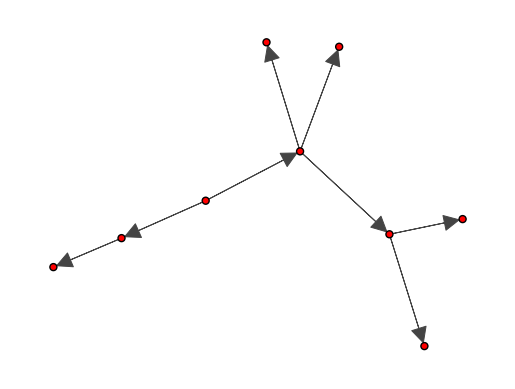

In [125]:

#cluster_index = 10
#nodes_subgraph = [v.index for v in g.vs if wcc.membership[v.index] == cluster_index]
component = g.subgraph(1)
#print(wcc.sizes())
#print(component)
fig, ax = plt.subplots()
ig.plot(
    wcc.subgraph(1),
    target=ax,
    palette=ig.RainbowPalette(),
    vertex_size=7,
    edge_width=0.7
)
plt.show()

## select the esges

ModuleNotFoundError: No module named 'PyVis'

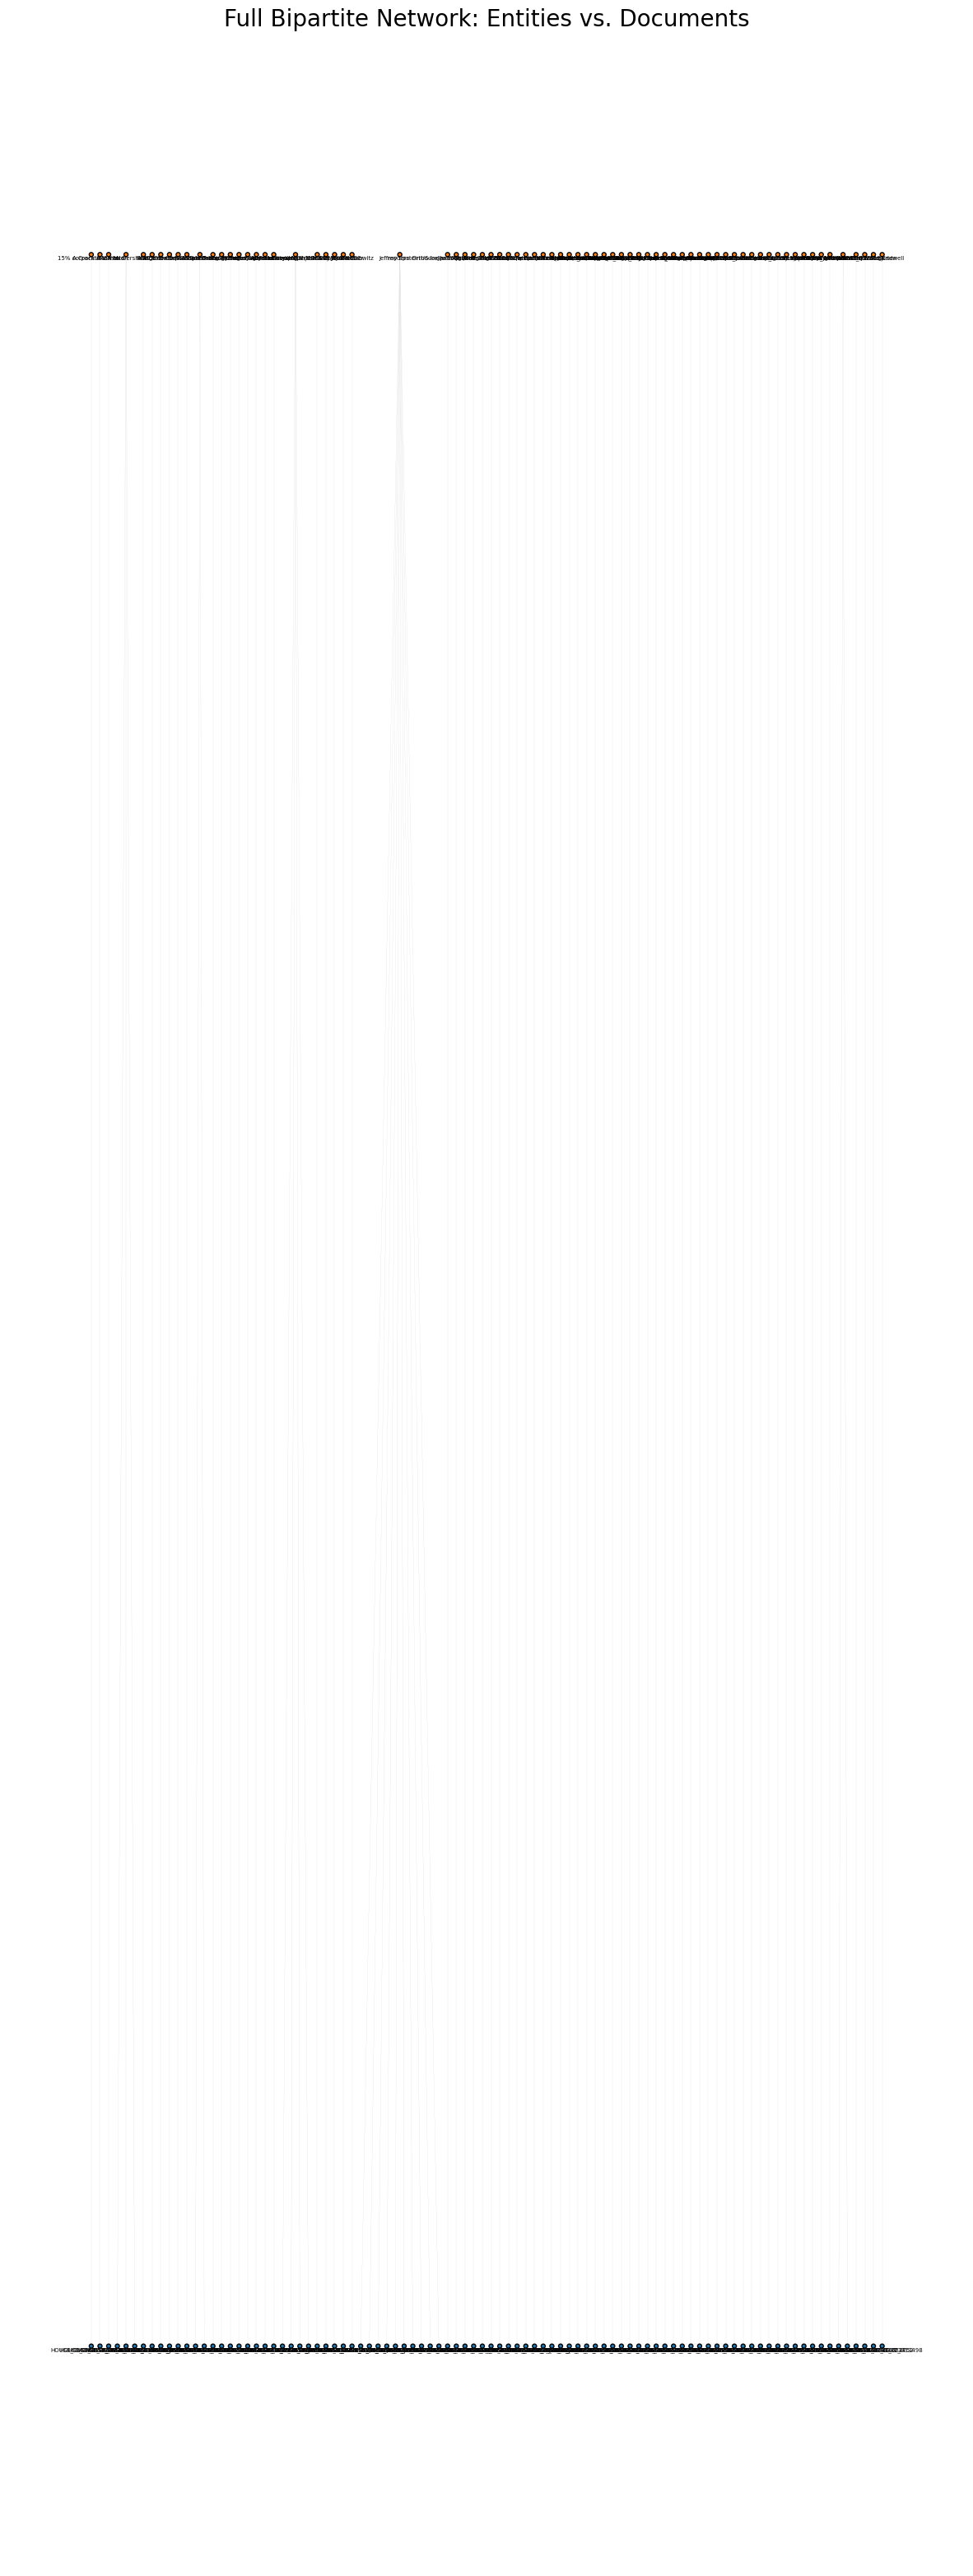

In [13]:
num_edges = g_bi.ecount()
sample_size = max(1, int(0.0005 * num_edges)) # Ensure at least 1 edge
sampled_edges = random.sample(range(num_edges), sample_size)
sub = g_bi.subgraph_edges(sampled_edges, delete_vertices=True)

# 1. Generate the Bipartite Layout on the FULL graph
# igraph uses the boolean 'type' attribute to put False on one side, True on the other


layout = sub.layout_bipartite(hgap=30, vgap=1)

# 2. Define Colors
# Orange for Entities (type == False), Blue for Documents (type == True)
colors = ["#FF7F0E" if t == False else "#1F77B4" for t in sub.vs["type"]]

# 3. Create a massive figure canvas
# 15 wide, 40 tall gives the vertical parallel lines room to breathe
fig, ax = plt.subplots(figsize=(15, 40)) 

# 4. Plot the graph
ig.plot(
    sub,
    target=ax,
    layout=layout,
    vertex_size=5,          # Very small nodes to prevent overlap
    vertex_color=colors,
    vertex_label=sub.vs["name"],
    vertex_label_size=5,    # Very small text
    vertex_label_dist=1.2,  # Pushes labels slightly outside the nodes
    edge_width=0.1,         # Extremely thin edges so you can see through the mass
    edge_color="#E0E0E0",   # Very light grey edges
    edge_arrow_size=0.2
)

ax.set_title("Full Bipartite Network: Entities vs. Documents", fontsize=20)
plt.axis('off') # Hides the axes box for a cleaner look
plt.show()

In [70]:
## Let's define the undirected version of it 
num_edges = g_bi.ecount()
sample_size = int(0.05 * num_edges)

sampled_edges = random.sample(range(num_edges), sample_size)

sub = g_bi.subgraph_edges(sampled_edges, delete_vertices=True)

layout = sub.layout("fr")  # Fruchterman-Reingold

ig.plot(
    sub,
    layout=layout,
    vertex_size=5,
    edge_arrow_size=0.2,
    bbox=(800, 800)
)

In [8]:
#Let's take a subgraph and plot it 
net = Network(height="750px", width="100%", directed=True)

# Add nodes
for v in sub.vs:
    title = f"Name: {v['name']}<br>Degree: <br>Betweenness:"
    net.add_node(v.index, label=v["name"], title=title)

# Add edges
for e in sub.es:
    # Add edge metadata if exists
    edge_title = ""
    for attr in [ "action"]:
        if attr in e.attributes():
            edge_title += f"{attr}: {e[attr]}<br>"
    net.add_edge(e.source, e.target, title=edge_title)


# Force-directed layout
net.force_atlas_2based()

# Save and render in Streamlit
net.save_graph("subgraph.html")
HtmlFile = open("subgraph.html", 'r', encoding='utf-8')
components.html(HtmlFile.read(), height=800, width=1000)

2026-02-20 18:05:54.168 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-20 18:05:54.651 
  command:

    streamlit run /Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/ipykernel_launcher.py [ARGUMENTS]
2026-02-20 18:05:54.652 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-02-20 18:05:54.654 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.


DeltaGenerator()

In [67]:

### From the bipartite graph I can project the graph to the nodes of type A 
### simply by joining the edge dataframe from A to B with the one from B to A 
### similarly with the projection on nodes of kind B

edges_entities = pd.merge(
    edges_AB, 
    edges_BA, 
    left_on='target',   # The doc_id in AB
    right_on='source',  # The doc_id in BA
    suffixes=('_actor', '_target')
)

print(edges_entities.columns)
print(edges_entities['source_actor'] == edges['actor'])
edges_doc = pd.merge(
    edges_BA, 
    edges_AB, 
    left_on='target', 
    right_on='source', 
    suffixes=('_source_doc', '_target_doc')
)


print(edges_doc.columns)


NameError: name 'edges_AB' is not defined